# A tutorial for NuQuLib 

In this tutorial, we explore key functionalities of NuQuLib, a quantum computing library for simulating nuclear systems. We cover the following topics:

1. Hamiltonian mapping  
   - a. Jordan–Wigner mapping of nuclear Hamiltonians  
   - b. Pairing Hamiltonian  
   - c. Comparison with chemical Hamiltonians  
2. Variational Quantum Eigensolver (VQE) example  
3. (Early-)FTQC algorithm example: QPE for small systems
4. State preparation with angular momentum projection

In [22]:
from scipy.special import comb
import seaborn as sns
import re
from nuqulib import *

def cnuc(nuc): # convert "2H" to "$^{2}$H"
    A = re.findall(r'\d+', nuc)
    element = nuc.replace(A[0], "")
    return f"$^{{{A[0]}}}${element}"

# My color palette
cols = sns.color_palette("deep", 10)
cols[0], cols[2] = cols[2], cols[0] 
cols[1], cols[3] = cols[3], cols[1] 

root_dir = "./"
int_file_path = root_dir + "tests/interaction_file/"
device_type = "CPU" # "CPU" or "GPU"

## 1. Hamiltonian mapping

### a) Jordan–Wigner mapping of nuclear Hamiltonians

In this section, we demonstrate the usage of `NuQuLib` for mapping shell-model Hamiltonians.

First, we read the `ckpot` effective interaction for the 0p shell (p1/2 and p3/2 orbitals on top of a 4He core) and map it to a qubit Hamiltonian using the Jordan–Wigner transformation.

NuQuLib can read interaction files for NN and 3N interactions, for example in `snt` format (`kshell.snt` in NuHamil).

You can (partially) check whether the mapping is correct by comparing the ground-state energy of fully occupied systems in the specified model space.

Below, we confirm correct results for both valence spaces (p, sd) and a few No-core shell model spaces.

#### valence space

We consider the following fully occupied systems in valence-shell model spaces:

- 16O in the p shell  
- 40Ca in the sd shell  



In [23]:
fns = ["ckpot.snt", "usdb.snt"]
ZNs = [ (8, 8), (20, 20) ]

for idx in range(len(fns)):
    filename_snt = int_file_path + fns[idx]
    print("filename_snt:", filename_snt)
    Z, N = ZNs[idx]
    hamil = Hamiltonian(filename_snt, Z, N)

    mapping_method = "JordanWigner"
    hamil.get_mscheme_H(opform=True)
    H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)
    H_1b = H_1b_p + H_1b_n

    n_qubits = hamil.n_qubits
    qc = QuantumCircuit(n_qubits)
    qc.x(range(n_qubits))  # prepare all qubits in |1> state

    # measurement of Hamiltonian
    estimator = StatevectorEstimator()
    job = estimator.run([(qc, H_1b), (qc, H_pp), (qc, H_nn), (qc, H_pn)])
    results = job.result()
    E_1b, E_pp, E_nn, E_pn = [ results[i].data.evs for i in range(len(results))]
    E_total = E_1b + E_pp + E_nn + E_pn 
    print("Etot", E_total, "E_1b: ", E_1b, "<pp>", E_pp, "<nn>", E_nn, "<pn>", E_pn)


filename_snt: ./tests/interaction_file/ckpot.snt
single_particle_states 0
dict_sps2msps {0: [0, 1], 1: [2, 3, 4, 5], 2: [6, 7], 3: [8, 9, 10, 11]}


0it [00:00, ?it/s]

# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...



100%|██████████| 262/262 [00:00<00:00, 4578781.87it/s]
3376it [00:00, 230934.35it/s]


Removing redundant terms... len= 3376  =>  777
Etot -113.81424999999999 E_1b:  18.708 <pp> -6.163999999999998 <nn> -6.163999999999998 <pn> -120.19424999999998
filename_snt: ./tests/interaction_file/usdb.snt
massop is set to 1. You may need to care about the mass number A=40 for your system
single_particle_states 0
dict_sps2msps {0: [0, 1], 1: [2, 3, 4, 5], 2: [6, 7, 8, 9, 10, 11], 3: [12, 13], 4: [14, 15, 16, 17], 5: [18, 19, 20, 21, 22, 23]}


0it [00:00, ?it/s]


# of H_m terms, 1b: 24, 2b pp: 620, nn: 620, pn: 3618 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...


100%|██████████| 2884/2884 [00:00<00:00, 10445917.73it/s]
41472it [00:00, 232589.10it/s]


Removing redundant terms... len= 41472  =>  9513
Etot -279.9607012333838 E_1b:  -43.04640000000002 <pp> -15.600464041796151 <nn> -15.600464041796151 <pn> -205.71337314979147


#### NCSM (no-core shell model) space

For nucleon-nucleon (NN) interaction, we use EM500 with SRG (1.8 fm\(^{-1}\) cutoff), in an harmonic oscillator (HO) basis with hw = 20 MeV and emax = 1. For three-nucleon (3N) interaction, we use the local-nonlocal (lnl) interaction.
Note that one can use [NuHamil code](https://github.com/Takayuki-Miyagi/NuHamil-public) to generate the NN and 3N interactions based on chiral effective field theory (EFT).

Note that results depend on the chosen interaction and Hamiltonian-generation settings.  
With a certain setting, the ground-state energy of \({}^{16}\mathrm{O}\) is expected to be \(-131.83565\) MeV.


In [24]:
emax = 1
filename_snt = int_file_path + "TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax1_e2max2.kshell.snt"
fn_3NF = int_file_path + "ThBME_lnl_ms1_2_1.readable.txt"
Z = proton_number  = N = neutron_number = 8

hamil = Hamiltonian(filename_snt, Z, N, ncsm=True, verbose=False, emax_truncate=emax,
                    e3max=emax, fn_3NF=fn_3NF)
mapping_method = "JordanWigner"
hamil.get_mscheme_H(opform=True)
H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)
H_1b = H_1b_p + H_1b_n

Hamil_NCSM_NN = H_1b + H_pp + H_nn + H_pn
hamil.set_mscheme_3NF()
H_3b = hamil.mapping_3NF_Mscheme()
Hamil_NCSM_NN3NF = Hamil_NCSM_NN + H_3b

n_qubits = hamil.n_qubits
qc = QuantumCircuit(n_qubits)
qc.x(range(n_qubits))  # prepare all qubits in |1> state

# measurement of Hamiltonian
estimator = StatevectorEstimator()
job = estimator.run([(qc, H_1b), (qc, H_pp), (qc, H_nn), (qc, H_pn), (qc, H_3b)])
results = job.result()
E_1b, E_pp, E_nn, E_pn, E_3n = [ results[i].data.evs for i in range(len(results))]
E_total = E_1b + E_pp + E_nn + E_pn + E_3n
print("Etot", E_total, "E(NN)", E_1b + E_pp + E_nn + E_pn)
print("E_1b: ", E_1b, "<pp>", E_pp, "<nn>", E_nn, "<pn>", E_pn, "<3b>", E_3n)

print("Example of NN+3NF terms:")
print(H_3b[:100:20])

single_particle_states 0
dict_sps2msps {0: [0, 1], 1: [2, 3], 2: [4, 5, 6, 7], 3: [8, 9], 4: [10, 11], 5: [12, 13, 14, 15]}
Setting up 3NF matrix elements in mscheme...


100%|██████████| 408/408 [00:00<00:00, 23890.49it/s]


Total number of 3NF matrix elements in M-scheme 15984


100%|██████████| 15984/15984 [00:00<00:00, 878188.07it/s]

# of H_m terms, 1b: 16, 2b pp: 83, nn: 83, pn: 456 v3b 2128
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...


...

Removing redundant terms... len= 6464  =>  1409
Encoding 3NF in JordanWigner mapping... # of 3NF terms: 2128


Removing redundant terms... len= 53632 => 2339
3NF mapping done in 0.28 sec.  8358.28 terms/sec
Setting up 3NF matrix elements in mscheme...


100%|██████████| 408/408 [00:00<00:00, 29178.26it/s]

Total number of 3NF matrix elements in M-scheme 15984
Encoding 3NF in Jordan-Wigner mapping... # of 3NF terms: 2128


Removing redundant terms... len= 53632 => 2339
3NF mapping done in 0.28 sec.  8215.26 terms/sec
Etot -131.83565105910458 E(NN) -148.36878574000022
E_1b:  337.5 <pp> -53.04027524000001 <nn> -70.00286417999999 <pn> -362.8256463200002 <3b> 16.53313468089563
Example of NN+3NF terms:
SparsePauliOp(['IIIIIIIIIIIIIIII', 'IIIIIIYXIIIIXYII', 'IIIIIIYYIIIIYYZI', 'IIIIIXXIIIIIIYYI', 'IIIIXZXIIIIIIYIY'],
              coeffs=[ 2.06664184+0.j, -0.03543338+0.j, -0.01771669+0.j, -0.03105602+0.j,
 -0.02241239+0.j])


### b) Pairing Hamiltonian

The pairing Hamiltonian is a simplified model of nuclear interaction (or BCS-type pairing).  
A Hamiltonian with global pairing interaction is given by

$$
H = \sum_{i} \epsilon_i a_i^{\dagger} a_i - \frac{g}{4} \sum{i,j} a_i^{\dagger} a_{\bar{i}}^{\dagger} a_{\bar{j}} a_j
$$

where \(a_i^\dagger\) and \(a_i\) are creation and annihilation operators for a nucleon in orbital \(i\), \(\epsilon_i\) is the single-particle energy, \(g\) is the pairing strength, and \(\bar{i}\) denotes the time-reversed orbital of \(i\).


In [25]:
Norb = 12
Nocc = 6
gval = 0.33
hamil = PairingHamiltonian(Norb, Nocc, gval)
Hamil_Pairing = hamil.encoding()

# Make a time evolution operator U = exp(-iHt)
delta_t = 0.1
Unitary_P = PauliEvolutionGate(Hamil_Pairing, delta_t, synthesis=SuzukiTrotter(order=1,reps=1))
print("U:", Unitary_P)

# Make a quantum circuit (1 ancilla + target qubits)
qc = QuantumCircuit(Norb+1)
Unitary_P = Unitary_P.control(1)
qc.append(Unitary_P, range(Norb+1))
qc = qc.decompose(reps=5)
print("# of gates, raw circuit:", qc.count_ops())

U: Instruction(name='PauliEvolution', num_qubits=12, num_clbits=0, params=[0.1])
# of gates, raw circuit: OrderedDict({'u': 1345, 'cx': 552})


### c) Chemical Hamiltonians

According to the PennyLane documentation [here](https://docs.pennylane.ai/en/stable/introduction/chemistry.html), the `qchem` module provides molecular Hamiltonians.

You can specify a molecule by its symbols and geometry, and generate its Hamiltonian with `qml.qchem.molecular_hamiltonian`.

Similarly, Qiskit provides molecular Hamiltonians through modules such as `qiskit_nature`.

In [26]:
symbols = ["Li", "H"]
geometry = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 2.969280527]])
molecule = qml.qchem.Molecule(symbols, geometry)
H, qubits = qml.qchem.molecular_hamiltonian(
    molecule,
    active_electrons=2,
    active_orbitals=5,
)
def circuit(params):
    qml.ApproxTimeEvolution(H, time=0.1, n=1)
    return [qml.expval(qml.PauliZ(i)) for i in range(qubits)]

dev = qml.device("default.qubit", wires=qubits)
params = np.random.rand(qubits)
compiled_qnode = qml.compile(
    qml.QNode(circuit, device=dev),
    basis_set=["CNOT", "RX", "RY", "RZ"])

spec = qml.specs(compiled_qnode)(params)

print("qubits:", qubits, "Gates:", dict(spec["resources"].gate_types))

qubits: 10 Gates: {'RZ': 1437, 'RX': 1186, 'CNOT': 2356}


## 2. Variational Quantum Eigensolver (VQE)

Many VQE implementations are available in quantum computing libraries (e.g., Qiskit and PennyLane), including unitary coupled-cluster (UCC) ansätze.

Here, we show a VQE example using the pair unitary coupled-cluster (pUCCD) ansatz adopted in the following paper:

S. Yoshida, T. Sato, T. Ogata, M. Kimura: [Phys. Rev. Research 8, 013134 (2026)](https://doi.org/10.1103/td9s-z7my)

NuQuLib provides fermionic representations of nuclear Hamiltonians, but direct use in VQE can be cumbersome, especially for NISQ-oriented workflows.  
Instead, we use the hard-core boson (HCB) mapping, which captures essential pairing correlations and is easier to implement on quantum hardware.

Below, we optimize the pUCCD ansatz for valence systems with even-number neutrons to estimate their ground state energies, comparing results with exact diagonalization to verify accuracy.

For valence two-neutron systems, ground-state energies are equivalent between fermionic and HCB representations, and the pUCCD ansatz can reach the exact value.

6He

/Users/sym4p/venv/lib/python3.12/site-packages/pennylane_lightning/lightning_base/_serialize.py:364: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs = np.array(coeffs).astype(self.rtype)


   E_FCI: -3.90981   Egs(6He; DOCI: -3.9098127922477905
# of parameters: 2  Nq_C_Nocc-1: 2
Params_opt:      -1.328457   1.798637
E_opt(pUCCD):          -3.909812792248 error (to DOCI)  8.88e-16 ( 0.000%)

18O   E_FCI: -11.93179   Egs(18O; DOCI: -11.931788760722092
# of parameters: 5  Nq_C_Nocc-1: 5
Params_opt:       1.067169  -1.263958   1.642946  -0.674698   0.716758
E_opt(pUCCD):         -11.931788760722 error (to DOCI)  0.00e+00 ( 0.000%)

20O   E_FCI: -23.63209   Egs(20O; DOCI: -23.146144774823366
# of parameters: 8  Nq_C_Nocc-1: 14
Params_opt:       4.709437  -1.783432   0.757648  -0.354354   7.159967  -1.029057   2.316676  -1.085312
E_opt(pUCCD):         -23.005955850100 error (to DOCI)  1.40e-01 ( 0.606%)

42Ca   E_FCI: -19.73368   Egs(42Ca; DOCI: -19.733675401085186
# of parameters: 9  Nq_C_Nocc-1: 9
Params_opt:      -1.031140   1.204976  -4.766289   8.773848   0.689627  -0.734740   0.790070  -4.857757   8.370531
E_opt(pUCCD):         -19.733675401085 error (to DOCI) -1.07e-14 

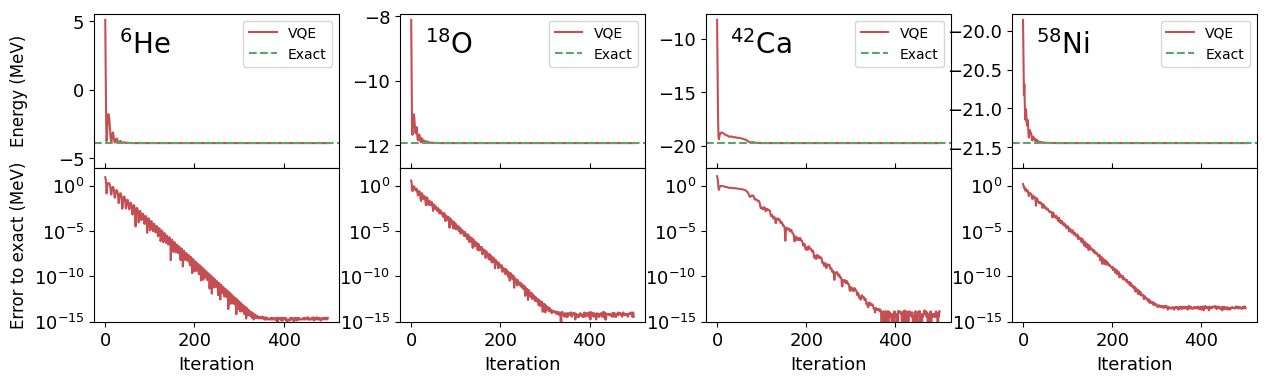

In [27]:
modelspace = {"p": {"msnt": "ckpot.msnt", 
                    "Acore":4, "Zcore":2, "Ncore":2, "pow_A": 1.0, "massop": 0,
                    "Nrange": range(4, 8, 2), "E_FCI": (-3.90981, -3.12306)},
              "sd": {"msnt": "usdb.msnt", 
                     "Acore":16, "Zcore":8, "Ncore":8, "pow_A": -0.3, "massop": 1,
                     "Nrange": range(10, 20, 2), "E_FCI": (-11.93179, -23.63209, -34.49787, -41.22531, -40.86881)},
              "pf": {"msnt": "gxpf1a.msnt", 
                     "Acore":40, "Zcore":20, "Ncore":20, "pow_A": -0.3, "massop": 1,
                     "Nrange": range(22, 40, 2), "E_FCI": (-19.73368, -38.67473, -56.66694, -73.66176, -85.05498, -95.36020, -102.63195, -104.58870, -106.66636)},
              "j45": {"msnt": "jun45.msnt",
                      "Acore": 56, "Zcore": 28, "Ncore": 28, "pow_A": -0.3, "massop": 1,
                      "Nrange": range(30, 50, 2), "E_FCI": (-21.44661, -41.27554, -59.60246, -76.44392, -91.94111, -106.13970, -119.03359, -130.92996, -141.93171, -152.10281)}}

Egs_FCI_dict = {}
for ms, subdict in modelspace.items():
    Zcore = subdict["Zcore"]
    Ncore = subdict["Ncore"]
    Z = 0 # assuming valence neutron systems
    for (idx_N, N) in enumerate(subdict["Nrange"]):
       A = Zcore + Z + N
       E_FCI = subdict["E_FCI"][idx_N]
       tkey = str(A)+element[Zcore+Z]
       Egs_FCI_dict[tkey] = E_FCI

N_it = 500
type_of_ansatz = "pUCCD"
tf_plot = True
Dict_Egs_pUCCD = {}

for ms in ["p", "sd", "pf", "j45"]:
    ## Specifying the target system and the Hamiltonian
    for idx in range(len(modelspace[ms]["Nrange"])):
        # For simplicity, we skip ones others than 6He, 18O, 20O, 42Ca, 58Ni
        tf = (idx == 0 or (ms == "sd" and idx <= 1))
        if not tf:
            continue

        Z = modelspace[ms]["Zcore"]
        N = modelspace[ms]["Nrange"][idx]
        A = Z + N
        nuc = str(A) + element[Z]
        adopted_ms = modelspace[ms]
        fn = int_file_path + adopted_ms["msnt"]; Acore = adopted_ms["Acore"]; Zcore = adopted_ms["Zcore"]; Ncore = adopted_ms["Ncore"]
        pow_A = adopted_ms["pow_A"]; massop = adopted_ms["massop"]
        vZ = Z - Zcore
        vN = N - Ncore
        Hamil, p_sps, n_sps, Dict_qubits_to_sps, Dict_sps_to_qubits = read_msnt(fn, A, Acore, pow_A=pow_A, massdep=massop)

        ## Setting up the qubits and Hamiltonian in the qubit representation
        Nocc = (A - Acore) // 2
        Nq = len(Dict_sps_to_qubits.keys())

        h1b, h2b = get_pairwise_Hamil(Hamil, n_sps)
        evals, evecs = eval_Hflat_eigen(Nq, Nocc, Hamil, h1b, h2b, Dict_qubits_to_sps)
        idx_min = np.argmin(evals)
        Egs_exact = evals[idx_min]
        gs_wf = evecs[:, idx_min] 
        hamiltonian_op = make_pw_hamil_qiskit(Hamil, h1b, Nq, Nocc, Dict_qubits_to_sps)

        ## Translating the Hamiltonian (Qiskit) to pennylane format
        coeffs_pl, obs_pl = transform_qiskitOps_to_pennylane(hamiltonian_op)
        Hamil_pl = qml.Hamiltonian(coeffs_pl, obs_pl)

        ## Preparing the ansatz
        params = np.zeros(1000, dtype=np.float64)
        dev = qml.device("lightning.qubit", wires=Nq)
        @qml.qnode(dev)
        def circuit(params_in):
            return pair_ansatz_pennylane(Hamil_pl, params_in, Nq, Nocc, type_of_ansatz="pUCCD")        
        where_is_G_or_cG1 = pair_ansatz_pennylane(Hamil_pl, params, Nq, Nocc, type_of_ansatz="pUCCD", return_Gdict=True)
        ngate = len(where_is_G_or_cG1.keys()) 
        params_pl = qnp.array(params[:ngate], requires_grad=True)
        optimizer = qml.AdamOptimizer(stepsize=0.5, beta2=0.998)
    
        energies = []
        Emin = 10**10
        params_opt = None
        for it in range(N_it):
            params_pl, _cost = optimizer.step_and_cost(circuit, params_pl)
            energies.append(_cost)
            if _cost <  Emin:
                Emin = _cost
                params_opt = params_pl

        print(nuc, "  E_FCI:", Egs_FCI_dict[nuc], "  Egs("+nuc+"; DOCI:", Egs_exact)
        print("# of parameters:", ngate, " Nq_C_Nocc-1:", comb(Nq, Nocc, exact=True)-1)
        print("Params_opt:    ", ' '.join( str("%10.6f" % i) for i in params_opt))
        print("E_opt(pUCCD):    ", str("%20.12f" % Emin),
                "error (to DOCI)", str("%9.2e" % (Emin - Egs_exact)), 
                "("+str("%6.3f" % (100*abs((Emin-Egs_exact)/Egs_exact)))+"%)\n")

        Dict_Egs_pUCCD[nuc] = {"Emin": Emin, "params": params_opt,
                            "x": range(N_it),
                            "y": energies, "ydiff": np.array(energies) - Egs_exact}

fig = plt.figure(figsize=(15,4))
axs = [fig.add_subplot(241), fig.add_subplot(242), fig.add_subplot(243), fig.add_subplot(244)]
for idx, ms in enumerate(["p", "sd", "pf", "j45"]):
    axs.append(fig.add_subplot(245+idx, sharex=axs[idx]))
    idx_u = idx
    idx_l = idx + 4
    nuc = ["6He", "18O", "42Ca", "58Ni"][idx]
    Egs_exact = Egs_FCI_dict[nuc]
    xpoints = Dict_Egs_pUCCD[nuc]["x"]
    ypoints = Dict_Egs_pUCCD[nuc]["y"]
    ydiff = Dict_Egs_pUCCD[nuc]["ydiff"]

    ax_u = axs[idx_u]
    if idx_u == 0:
        ax_u.set_ylabel("Energy (MeV)", fontsize=12)
    ax_u.plot(xpoints, ypoints, color=cols[1], label="VQE")
    ax_u.text(0.1, 0.9, latex_nuc(nuc), ha="left", va="top", transform=ax_u.transAxes, fontsize=20)
    ax_u.axhline(y=Egs_exact, color=cols[0], linestyle="--", label="Exact")
    ax_u.legend(loc="upper right")
    ax_u.set_ylim(bottom= Egs_exact - 0.2 * abs(Egs_exact-np.max(ypoints)))
    ax_u.tick_params(axis='both', labelsize=13) 
    
    ax_l = axs[idx_l]
    ax_l.set_xlabel("Iteration", fontsize=13)
    ax_l.set_yscale("log")
    ax_l.plot(xpoints, ydiff, color=cols[1])
    ax_l.tick_params(axis='x', which='both', top=True)
    ax_l.set_ylim(bottom=1e-15, top=1e+2)
    ax_l.tick_params(axis='both', labelsize=13) 
    if idx_l == 4:
        #ax_l.set_ylabel("Error to DOCI/FCI (MeV)", fontsize=11)
        ax_l.set_ylabel("Error to exact (MeV)", fontsize=12)
    
fig.align_ylabels([axs[0], axs[4]])
fig.align_ylabels([axs[1], axs[5]])
fig.align_ylabels([axs[2], axs[6]])
fig.align_ylabels([axs[3], axs[7]])
plt.subplots_adjust(hspace=0, wspace=0.25)
plt.savefig("VQE_pUCCD.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()
plt.close()

## 3. Quantum Phase Estimation (QPE)

In this section, we demonstrate Quantum Phase Estimation (QPE) with NuQuLib for a small system, ${}^{6}$He in the 0p shell with the CKpot interaction.

In [28]:
n_ancilla = 6
trotter_order = 4
trotter_steps = 10
delta_t = 0.2
size_Eshift = 10.0

In [29]:
def plot_spectrum(n_ancilla, delta_t, target, nuc, Energy_list, Ens_exact, Jvals, save_fig=False):
    linetypes = ["solid", "dashed", "dotted", "dashdot"]
    
    if target == "NN":
        int_type = "NN-only" 
    elif target == "NN3NF":
        int_type = "NN+3NF"
    elif target == "valence":
        int_type = "Valence-space"
    else:
        int_type = ""

    fn_plot = "qpe_results_" + target + "_" + nuc + f"_Na{n_ancilla}.pdf"
    fig = plt.figure(figsize=(5,3))
    ax = fig.add_subplot(1,1,1)
    ax.set_yscale("log")
    ax.set_xlabel("Energy (MeV)")
    ax.set_ylabel("Probability Density")
    ax.set_ylim(bottom=1e-3, top=5.0)
    barwidth = abs(2 * np.pi / (delta_t * 2**n_ancilla) * 0.8)
    ax.bar([energy for energy, p in Energy_list], 
            [p for energy, p in Energy_list], 
            width=barwidth, color=cols[0], alpha=0.8, zorder=100)

    Jhit = [ ]
    for idx, E in enumerate(Ens_exact):
        J2val = int(round(Jvals[idx]*2, 1))
        Jidx = J2val // 2
        if not (Jidx, J2val) in Jhit:
            Jhit.append((Jidx, J2val))
        linestyle = linetypes[Jidx]
        print(f"Energy: {E:.6f} MeV, J: {J2val} Jidx={Jidx}, linestyle: {linestyle}")
        ax.axvline(E, color= "k", linestyle=linestyle, alpha=0.8, zorder=0)
    target = "NN-only" if target == "NN" else "NN+3NF"
    ax.text(0.03, 0.95, cnuc(nuc)+": " + int_type, transform=ax.transAxes, fontsize=14, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"))
    Emin = min(Ens_exact[0]*2, Ens_exact[0]*0.5)
    Emax = max(Ens_exact[-1]*1.5, Ens_exact[-1]*0.5)
    # Jvalue legend (original legend is reordered by J)
    legend_elements = []
    for Jidx, J2val in sorted(Jhit):
        linestyle = linetypes[Jidx]
        if J2val % 2 == 0:
            label = f"$\\mathrm{{J}}={int(J2val/2)}$"
        else:
            label = f"$\\mathrm{{J}}={J2val}/2$"
        legend_elements.append(plt.Line2D([0], [0], color="k", linestyle=linestyle, alpha=0.8, label=label))

    ax.legend(handles=legend_elements, loc="upper right", fontsize=11)
    ax.set_xlim(Emin, Emax)
    if save_fig:
        plt.savefig(fn_plot, bbox_inches='tight', pad_inches=0.05)
    plt.show()
    plt.close()


single_particle_states 2
dict_sps2msps {2: [0, 1], 3: [2, 3, 4, 5]}


0it [00:00, ?it/s]

# of H_m terms, 1b: 6, 2b pp: 0, nn: 43, pn: 0 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using Jordan-Wigner...



0it [00:00, ?it/s]

Nq: 6 n_qubit_p: 0 n_qubit_n: 6 Z: 2 N: 4
<H>: [-3.90981246  0.6322095   4.1172905   4.2824      7.92111246]
<J>: [0. 2. 2. 1. 0.]
Energy expectation value of the prepared state: 0.637550 MeV
Running QPE circuit with statevector simulator...


Bitstring: 001110, Energy: -3.744468 MeV, Probability: 0.264201
Bitstring: 110010, Energy: 0.673397 MeV, Probability: 0.250936
Bitstring: 001100, Energy: 4.109514 MeV, Probability: 0.241995
Bitstring: 001000, Energy: 8.036505 MeV, Probability: 0.104028
Bitstring: 101110, Energy: -4.235342 MeV, Probability: 0.061812
Bitstring: 110110, Energy: -3.253594 MeV, Probability: 0.014357
Bitstring: 011110, Energy: -4.726216 MeV, Probability: 0.011605
Bitstring: 101000, Energy: 7.545631 MeV, Probability: 0.007349
Bitstring: 010110, Energy: -2.762720 MeV, Probability: 0.005875
Bitstring: 111110, Energy: -5.217089 MeV, Probability: 0.003819
Energy: -3.909812 MeV, J: 0 Jidx=0, linestyle: solid
Energy: 0.632210 MeV, J: 4 Jidx=2, linestyle: dotted
Energy: 4.117290 MeV, J: 4 Jidx=2, linestyle: dotted
Energy: 4.282400 MeV, J: 2 Jidx=1, linestyle: dashed
Energy: 7.921112 MeV, J: 0 Jidx=0, linestyle: solid


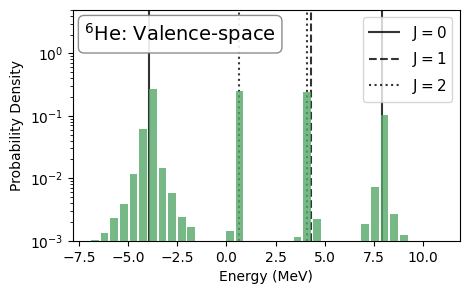

In [30]:
ncsm = False

# NCSM
if ncsm:
    target = "NN3NF"
    Zc = Nc = 0
    emax = e3max = 1
    fn_snt = int_file_path + f"TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax{emax}_e2max{emax*2}.kshell.snt"
    fn_3NF = int_file_path + "ThBME_lnl_ms1_2_1.readable.txt"
    #fn_3NF = None; target = "NN-only"
    nuc = "3n"; Z = proton_number = 0; N = neutron_number = 3; qrange = [0, 1, 6]; target_parity = -1; size_Eshift = 0.0
    single_spiecies = 2
    delta_t = - 0.1
else:
    target = "valence"
    fn_snt = int_file_path+"ckpot.snt"; Zc = Nc = 2
    nuc = "He6"; Z = 2; N = 4 
    qrange = [8, 11]; single_spiecies = 0
    qrange = [2, 5]; single_spiecies = 2
    target_parity = 1 
    
if ncsm:
    hamil, Hamil_mapped, proton_qubits, neutron_qubits = get_Hamiltonian(fn_snt, Z, N, ncsm=ncsm, emax=emax, e3max=e3max, fn_3NF=fn_3NF, single_spiecies=single_spiecies)
else:
    hamil, Hamil_mapped, proton_qubits, neutron_qubits = get_Hamiltonian(fn_snt, Z, N, single_spiecies=single_spiecies)

n_qubit_p = hamil.n_qubits_p
n_qubit_n = hamil.n_qubits_n
Nq = n_qubit_p + n_qubit_n
print("Nq:", Nq, "n_qubit_p:", n_qubit_p, "n_qubit_n:", n_qubit_n, "Z:", Z, "N:", N)

# Brute force diagonalization for comparison: `Diagonalize_Hamiltonian` in src/nuqulib/diagonalization.py
obj_Diag = Diagonalize_Hamiltonian(Hamil_mapped, hamil, Z, N, target_parity, Zc, Nc)
basis = obj_Diag["basis"]
Hsub = obj_Diag["Hsub"]
Ens_exact = obj_Diag["evals"]
Jvals = obj_Diag["Jvals"]
print("<H>:", Ens_exact)
print("<J>:", Jvals)

# State preparation
U_prep = QuantumCircuit(Nq)
for q in qrange:
    U_prep.x(q)

# Energy check
sim = AerSimulator(method='statevector', device=device_type)
psi = U_prep.remove_final_measurements(inplace=False)
psi.save_statevector()
tqc = transpile(psi, sim)
job = sim.run(tqc)
result = job.result()
psi_final = result.get_statevector(tqc)
E_expect = psi_final.expectation_value(Hamil_mapped).real 
print(f"Energy expectation value of the prepared state: {E_expect:.6f} MeV")

# Energy shift
Hamil_shifted = Hamil_mapped - size_Eshift * SparsePauliOp("I" * Nq)

# Construct QPE circuit
qc_QPE = circuit_my_QPE(n_ancilla, Nq, Hamil_shifted, U_prep, delta_t, trotter_order=trotter_order, trotter_steps=trotter_steps)
qc_sv = qc_QPE.remove_final_measurements(inplace=False)
qc_sv.save_statevector()

# Run Aer statevector simulator
print("Running QPE circuit with statevector simulator...")
sim = AerSimulator(method='statevector', device=device_type)
tqc = transpile(qc_sv, sim)
job = sim.run(tqc)
result = job.result()
psi_final = result.get_statevector(tqc)

# Get probabilities on ancilla register only
anc_idx = [qc_QPE.qubits.index(q) for q in qc_QPE.qregs[0]]
probs = psi_final.probabilities_dict(qargs=anc_idx)

list_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
summarized_probs = {} 
for bitstring_whole, p in list_probs:
    bitstring = bitstring_whole[:n_ancilla]
    if bitstring in summarized_probs:
        summarized_probs[bitstring] += p
    else:
        summarized_probs[bitstring] = p
list_probs = sorted(summarized_probs.items(), key=lambda x: x[1], reverse=True)

Energy_list = []
for idx, (bitstring, p) in enumerate(list_probs):
    energy = 2 * np.pi * int(bitstring[::-1], 2) / (-delta_t * (2**n_ancilla))
    energy += size_Eshift
    Energy_list.append((energy, p))
    if idx < 10:
        print(f"Bitstring: {bitstring}, Energy: {energy:.6f} MeV, Probability: {p:.6f}")
plot_spectrum(n_ancilla, delta_t, target, nuc, Energy_list, Ens_exact, Jvals, save_fig=True)

One can see four peaks by QPE.
This seems the issue of resolution of QPE (governed by the number of ancilla qubits and Trotter steps),
but actually, the fourth state has no overlap with the initial state made by naive filling of the p3/2 orbital, and thus it is not obtained by QPE.

## Observable Dynamic Mode Decomposition (ODMD)

ODMD method is a quantum algorithm for simulating the eigen spectrum of quantum systems. It is based on the idea of dynamic mode decomposition (DMD), which is a data-driven method for analyzing the dynamics of complex systems such as fluid dynamics. ODMD extends DMD to quantum systems by using quantum circuits to represent the time evolution operator and the observables of interest.

Ref: Y. Shen et al., [Quantum 9, 1836 (2025)](https://doi.org/10.22331/q-2025-08-27-1836)

For the ODMD demonstration (and the subsequent QKrylov method), we adopt the HCB mapping of the nuclear Hamiltonian. Fermionic representations generally produce longer Pauli strings and thus higher computational cost.  
The time step for ODMD is set to \(1\times10^{-2}\), smaller than that used in QPE.


In [31]:
delta_t_ODMD = 0.1
trotter_order = 4
trotter_steps = 10

## Specifying the target system and the Hamiltonian
ms = "sd"
idx = 1
Z = modelspace[ms]["Zcore"]
N = modelspace[ms]["Nrange"][idx]
A = Z + N
nuc = str(A) + element[Z]
adopted_ms = modelspace[ms]
fn = int_file_path + adopted_ms["msnt"]; Acore = adopted_ms["Acore"]; Zcore = adopted_ms["Zcore"]; Ncore = adopted_ms["Ncore"]
pow_A = adopted_ms["pow_A"]; massop = adopted_ms["massop"]
vZ = Z - Zcore
vN = N - Ncore
Hamil, p_sps, n_sps, Dict_qubits_to_sps, Dict_sps_to_qubits = read_msnt(fn, A, Acore, pow_A=pow_A, massdep=massop)

## Setting up the qubits and Hamiltonian in the qubit representation
Nocc = (A - Acore) // 2
Nq = len(Dict_sps_to_qubits.keys())

h1b, h2b = get_pairwise_Hamil(Hamil, n_sps)
evals, evecs = eval_Hflat_eigen(Nq, Nocc, Hamil, h1b, h2b, Dict_qubits_to_sps)
idx_min = np.argmin(evals)
Egs_exact = evals[idx_min]
gs_wf = evecs[:, idx_min] 
hamiltonian_op = make_pw_hamil_qiskit(Hamil, h1b, Nq, Nocc, Dict_qubits_to_sps)

sampler = AerSimulator(method="statevector", device=device_type)
ancilla_qubits = [0]
target_qubits = list(range(1, Nq+1))

dim_Hankel = 15
max_iterations = 30
np.random.seed(42)
params = np.array(Dict_Egs_pUCCD[nuc]["params"]) + np.random.randn(Nocc*(Nq-Nocc))
qc_ansatz = pair_ansatz_qiskit(params, Nq, Nocc, method="pUCCD", decent_order=True)

odmd = ODMD(
    qc_ansatz,
    hamiltonian_op,
    delta_t_ODMD,
    max_iterations,
    trotter_order,
    trotter_steps,
    sampler,
    ancilla_qubits,
    target_qubits,
    dim_Hankel=dim_Hankel,
    tol_lambda=0.05,
    verbose=False,
    )

print("T-count for ODMD with eps=1e-10 (Ross-Selinger model):")
odmd.estimate_resource(tol=1e-10, model="ross-selinger")

Ens_ODMD, lams_ODMD = odmd.run()
print("Ens from ODMD:", "".join([f"{tmp:8.3f} " for tmp in np.sort(Ens_ODMD)]))
print("Evals (DOCI): ",  "".join([f"{tmp:8.3f} " for tmp in np.sort(evals[:10])]))

# Examples of additional information now accessible from the class instance
print("ODMD fit error |AX-Y|:", odmd.fit_error)
print("ODMD selected rank:", odmd.trank)
print("ODMD effective tol_lambda:", odmd.tol_lambda_used)

T-count for ODMD with eps=1e-10 (Ross-Selinger model):
Estimating resource for ODMD with Niter=30, eps=1.0e-10: 
T-count formula: Nshot * T_cU * T_epsilon * max_iterations * (max_iterations + 1) = 379440000 log10: 8.6


  3%|▎         | 1/29 [00:04<02:02,  4.38s/it]

overlap @  1: (0.03346171938440956+0.6889358738206929j)


  7%|▋         | 2/29 [00:08<01:58,  4.39s/it]

overlap @  2: (-0.06176471050011495-0.058286011449945885j)


...

overlap @ 27: (0.7506131223620516-0.1941619662574267j)


 97%|█████████▋| 28/29 [02:07<00:04,  4.61s/it]

overlap @ 28: (0.08832835668037398+0.5194289969071026j)


100%|██████████| 29/29 [02:11<00:00,  4.54s/it]

overlap @ 29: (-0.014620258056045499-0.15458698682073613j)
Max iteration:    30 trotter_steps:    10 delta_t:   0.10000000  tol for lambda = 5.00e-02
Check |AX - Y| 1.298876842145793e-06
Ens from ODMD:  -23.155  -19.631  -16.148   -9.184   -6.930   -4.408    6.909 
Evals (DOCI):   -23.146  -20.357  -19.536  -18.134  -16.733  -15.865   -9.236   -8.231   -3.202    6.907 
ODMD fit error |AX-Y|: 1.298876842145793e-06
ODMD selected rank: None
ODMD effective tol_lambda: 0.05


## Quantum Krylov subspace method (QKrylov)

QKrylov is a quantum algorithm for finding eigenvalues and eigenvectors of a Hamiltonian, based on the idea of Krylov subspace methods, which are often used in classical computing for solving quantum many-body problems.

We use the same pUCCD ansatz as in the VQE example as the initial state, with slight parameter perturbations so that the initial state is not exactly the ground state.

In [32]:
delta_t_QKrylov = 0.4
max_iterations = 15

In [33]:
## Specifying the target system and the Hamiltonian
ms = "sd"
idx = 1
Z = modelspace[ms]["Zcore"]
N = modelspace[ms]["Nrange"][idx]
A = Z + N
nuc = str(A) + element[Z]
adopted_ms = modelspace[ms]
fn = int_file_path + adopted_ms["msnt"]; Acore = adopted_ms["Acore"]; Zcore = adopted_ms["Zcore"]; Ncore = adopted_ms["Ncore"]
pow_A = adopted_ms["pow_A"]; massop = adopted_ms["massop"]
vZ = Z - Zcore
vN = N - Ncore
Hamil, p_sps, n_sps, Dict_qubits_to_sps, Dict_sps_to_qubits = read_msnt(fn, A, Acore, pow_A=pow_A, massdep=massop)

## Setting up the qubits and Hamiltonian in the qubit representation
Nocc = (A - Acore) // 2
Nq = len(Dict_sps_to_qubits.keys())

h1b, h2b = get_pairwise_Hamil(Hamil, n_sps)
evals, evecs = eval_Hflat_eigen(Nq, Nocc, Hamil, h1b, h2b, Dict_qubits_to_sps)
idx_min = np.argmin(evals)
Egs_exact = evals[idx_min]
gs_wf = evecs[:, idx_min] 
hamiltonian_op = make_pw_hamil_qiskit(Hamil, h1b, Nq, Nocc, Dict_qubits_to_sps)

In [34]:
print("Target nucleus:", nuc)
sampler = AerSimulator(method="statevector", device=device_type)
ancilla_qubits = [0]
target_qubits = list(range(1, Nq+1))

np.random.seed(42)
init_params = np.array(Dict_Egs_pUCCD[nuc]["params"]) + 0.5 * np.random.randn(Nocc*(Nq-Nocc))
qc_ansatz = pair_ansatz_qiskit(init_params, Nq, Nocc, method="pUCCD", decent_order=True)   

res_QKrylov = QuantumKrylov(qc_ansatz, hamiltonian_op, sampler,
                            ancilla_qubits, target_qubits,
                            delta_t_QKrylov,
                            trotter_rank=trotter_order, trotter_steps=trotter_steps, 
                            max_iterations=max_iterations,
                            using_statevector=True, Bosonic=True, verbose=True)

Target nucleus: 20O
num of Hamil term:  52


  0%|          | 0/15 [00:00<?, ?it/s]

iteration:  0


  7%|▋         | 1/15 [00:00<00:10,  1.38it/s]

H[diag=0] = (-20.676941158769118+0j)
eigs of N:  [1.] cond 1.0 r: 1
w: [-20.67694116]

iteration:  1
H[diag=1] = (-20.67695148791837+0j)


...

H[off-diag=12,0] = (-7.908427589025484+1.9700478689524261j)
eigs of N:  [2.51936426e-05 6.74485503e-04 5.74114786e-03 1.83835258e-02
 3.34997077e-02 1.05326579e-01 1.31202911e-01 2.57615465e-01
 4.25076734e-01 5.69057149e-01 7.94320188e-01 1.46878599e+00
 9.19029092e+00] cond 364786.1109030781 r: 13
w: [-23.11672955 -20.10192861 -18.74042397 -17.32781592 -16.63200777
 -15.76660137  -9.23446541  -8.19755948  -6.8409619   -6.12732579
  -5.3610477   -4.4837755    6.84144146]

iteration:  13
H[diag=13] = (-15.921537880603696+0j)
H[off-diag=13,12] = (6.1455923638674586-2.0520364948737626j)
H[off-diag=13,11] = (12.937290160385308-7.03359639297852j)
H[off-diag=13,10] = (-8.888555768316376-0.7254548784816275j)
H[off-diag=13,9] = (5.830034154251092+9.338496983840859j)
H[off-diag=13,8] = (-6.6463473888277385-15.919416836164654j)
H[off-diag=13,7] = (3.738535678844047+16.596264684494308j)
H[off-diag=13,6] = (-1.5027745072640766-16.747145810328718j)
H[off-diag=13,5] = (-0.4727845949653776+16.412762

 93%|█████████▎| 14/15 [34:46<04:08, 248.16s/it]

H[off-diag=13,0] = (13.664273940864573-10.189092597999414j)
eigs of N:  [1.88361712e-05 4.05182228e-04 4.40080857e-03 1.48850500e-02
 2.06976196e-02 4.35741621e-02 1.28966010e-01 1.84242205e-01
 3.19073761e-01 4.75254271e-01 6.16896239e-01 8.30949244e-01
 1.52650332e+00 9.83413329e+00] cond 522087.7007417045 r: 14
w: [-23.14304155 -20.26938303 -19.18134361 -17.41815803 -16.64273692
 -15.77473792  -9.23505042  -8.21792056  -6.92857171  -6.71741615
  -5.37343568  -4.49866374  -3.30865672   6.85208907]

iteration:  14
H[diag=14] = (-14.465004233826601+0j)
H[off-diag=14,13] = (13.00496783015829+4.255567771104106j)
H[off-diag=14,12] = (-5.052515217503302-1.5450292336929725j)
H[off-diag=14,11] = (-10.659636864314004+3.383649798041866j)
H[off-diag=14,10] = (8.725230698824024+2.508753842365193j)
H[off-diag=14,9] = (-3.2858434473579257-10.0329223980555j)
H[off-diag=14,8] = (3.152037002551024+15.238323888729829j)
H[off-diag=14,7] = (0.45512567748211064-14.948175145660443j)
H[off-diag=14,6] = (-2

100%|██████████| 15/15 [40:07<00:00, 160.52s/it]

H[off-diag=14,0] = (-13.55121527797803+7.4172867228728885j)
eigs of N:  [1.69347659e-05 3.77235860e-04 2.70295499e-03 1.38724619e-02
 2.04634579e-02 3.15882872e-02 9.77648994e-02 1.68230481e-01
 2.03975912e-01 3.27921948e-01 5.15681879e-01 7.51713381e-01
 8.86124721e-01 1.55516086e+00 1.04244046e+01] cond 615562.3680713925 r: 15
w: [-23.14614477 -20.35715287 -19.53595313 -18.13406683 -16.73279509
 -15.86548169  -9.2359111   -8.23106987  -6.95542414  -6.75876207
  -5.38636668  -4.68350665  -4.39876591  -3.20177848   6.9074042 ]



In [35]:
Results_ODMD = [ ]
shapes = [(5,5), (10, 10)]
for (nrow_Hankel, ncol_Hankel) in shapes:
    if nrow_Hankel + ncol_Hankel >= len(odmd.snapshots):
        print(f"Skipping Hankel shape ({nrow_Hankel}, {ncol_Hankel}) since it requires at least {nrow_Hankel + ncol_Hankel} snapshots, which exceeds the number of available snapshots.")
        continue
    print(f"Hankel.shape = ({nrow_Hankel}, {ncol_Hankel})")
    subdim = nrow_Hankel + ncol_Hankel
    sub_snapshots = odmd.snapshots[:subdim]
    X, Y = odmd.construct_X_and_Y(sub_snapshots, dim_Hankel=nrow_Hankel)
    A = odmd.construct_A_from_XY(X, Y)
    print("shape:", X.shape)
    fit_error = np.linalg.norm(A @ X - Y)
    print("Check |AX - Y|", fit_error)

    # Eigen values of A would be exp(-iE_j dt)
    lams, v = np.linalg.eig(A)
    tol_lambda_used = odmd.tol_lambda
    selected_indices = []
    while len(selected_indices) == 0:
        selected_indices = [
            i for i in range(len(lams)) if np.abs(np.abs(lams[i]) - 1) < tol_lambda_used
        ]
        if len(selected_indices) == 0:
            print(f"No eigenvalue found within |lambda|=1 +/- {tol_lambda_used:8.2e}.")
            print("Increasing the tolerance by a factor of 10.")
            tol_lambda_used *= 10

    selected_lams = lams[selected_indices]
    arg_lam = np.angle(selected_lams)
    energies = list(-(arg_lam) / odmd.delta_t)
    print("E(ODMD):", "".join([f"{tmp:8.3f} " for tmp in np.sort(energies)]),"\n")
    Results_ODMD.append({"shape": (nrow_Hankel, ncol_Hankel), "energies": energies})

Hankel.shape = (5, 5)
shape: (5, 5)
Check |AX - Y| 2.132596117954469e-15
E(ODMD):  -23.151  -18.952    6.902  

Hankel.shape = (10, 10)
shape: (10, 10)
Check |AX - Y| 2.7256566701393007e-14
E(ODMD):  -23.154  -19.639  -16.131   -9.176   -6.935   -4.423    6.907  



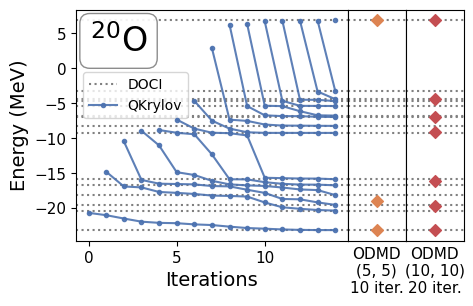

In [36]:
En_history = res_QKrylov[2]
Ens = []
num_states = len(evals)
for iter in range(len(En_history)):
    tmp = [None for _ in range(num_states)]
    for i in range(len(En_history[iter])):
        tmp[i] = En_history[iter][i]
    Ens.append(tmp)

# axs[0]: convergence pattern of QKrylov
# axs[1]: ODMD with setup-A
# axs[2]: ODMD with setup-B
fig, axs = plt.subplots(1, 3,
    gridspec_kw=dict(width_ratios=[7, 1.5, 1.5], wspace=0),
    sharey='row', figsize=(5, 3)
)

axs[0].set_xlabel("Iterations", fontsize=14)
axs[1].set_xlabel(f"ODMD\n{Results_ODMD[0]["shape"]}\n{np.sum(Results_ODMD[0]["shape"])} iter.", fontsize=11)
axs[2].set_xlabel(f"ODMD\n{Results_ODMD[1]["shape"]}\n{np.sum(Results_ODMD[1]["shape"])} iter.", fontsize=11)
axs[0].set_ylabel("Energy (MeV)", fontsize=14)

evals = np.sort(evals)
for (n, eval) in enumerate(evals):
    for (iax, ax) in enumerate(axs):
        ax.axhline(eval, color="gray", linestyle="dotted", label="DOCI" if (n==0 and iax == 0) else None)

for i in range(num_states):
    axs[0].plot(range(len(En_history)), 
                [Ens[iter][i] for iter in range(len(En_history))], 
                marker = "o", markersize=3, 
                color = cols[2],
                alpha=0.9,
                zorder=100, label="QKrylov" if i==0 else None)
for iax in range(len(Results_ODMD)):
    tmp = Results_ODMD[iax]
    Ens = tmp["energies"]
    axs[1+iax].scatter([0]*len(Ens), Ens, color=cols[3-2*iax], marker="D", zorder = 100)
    axs[1+iax].tick_params(bottom=False, left=False, right=False, top=False,
                           labelbottom=False)

axs[0].tick_params(axis='both', labelsize=11)
axs[0].text(0.05, 0.94, cnuc(nuc), ha="left", va="top", transform=axs[0].transAxes, fontsize=24, 
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"))
axs[0].legend(bbox_to_anchor=(0, 0.63), loc="center left")
plt.savefig("QKrylov_ODMD_Ens_" + nuc + ".pdf", bbox_inches="tight", pad_inches=0.01)
plt.show()
plt.close()

## State preparation with angular momentum projection



In [37]:
num_projection_steps = 5
Na = 1
np.random.seed(2)

In [38]:
fn_snt = "tests/interaction_file/ckpot.snt"
Zc = Nc = 2
nuc = "He6"; Z = 2; N = 4
target_parity = 1
num_Jz_projections = 2 

fn_snt = "tests/interaction_file/usdb.snt"
Zc = Nc = 8
nuc = "O18"; Z = 8; N = 10
target_parity = 1
num_Jz_projections = 3

In [39]:
hamil, H_mapped, proton_qubits, neutron_qubits = get_Hamiltonian(fn_snt, Z, N, single_spiecies=2)
n_qubit_p = hamil.n_qubits_p
n_qubit_n = hamil.n_qubits_n
Nq = n_qubit_p + n_qubit_n

# Brute force diagonalization for comparison: `Diagonalize_Hamiltonian` in src/nuqulib/diagonalization.py
obj_Diag = Diagonalize_Hamiltonian(H_mapped, hamil, Z, N, target_parity, Zc, Nc, calc_J2=True)
print("<H>:", obj_Diag["evals"])
print("<J>:", obj_Diag["Jvals"])
obj_Diag = Diagonalize_Hamiltonian(H_mapped, hamil, Z, N, target_parity, Zc, Nc, use_basis=None, calc_J2=False)

Ens_exact = obj_Diag["evals"]
evecs_exact = obj_Diag["evecs"]

massop is set to 1. You may need to care about the mass number A=18 for your system
single_particle_states 2
dict_sps2msps {3: [0, 1], 4: [2, 3, 4, 5], 5: [6, 7, 8, 9, 10, 11]}


0it [00:00, ?it/s]

# of H_m terms, 1b: 12, 2b pp: 0, nn: 620, pn: 0 v3b 0


Mapping p-n Hamiltonian terms to Pauli strings using Jordan-Wigner...


0it [00:00, ?it/s]


<H>: [-11.93178825  -9.93334581  -8.40458777  -7.57171041  -7.33926256
  -6.50542084  -2.91241223  -2.05051016  -1.16197539  -0.99077916
  -0.90106753  -0.57682461   3.07695081   4.28833391]
<J>: [0. 2. 4. 2. 0. 3. 4. 2. 1. 3. 2. 1. 0. 2.]
One may consider to use Krylov subspace methods.


Starting from a state prepared by lowest-filling plus some particle-hole excitations, we can project the state onto the J=0 subspace using the angular momentum projection operator.

In [40]:
proton_qubits = list(range(n_qubit_p))
neutron_qubits = list(range(n_qubit_p, Nq))
print(f"Proton qubits: {proton_qubits}")
print(f"Neutron qubits: {neutron_qubits}")
qr_ancilla = range(Na)
qr_target = range(Na, Na + Nq)

theta = np.random.randn(Nq**2) 

Uprep = nucl_ansatz(
    hamil.Hamildict, Nq, proton_qubits, neutron_qubits, Z-Zc, N-Nc,
    params = theta,
    method = "HF+Givens"
)

Proton qubits: []
Neutron qubits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


In [41]:
sim = AerSimulator(method='statevector', device=device_type)

In [42]:
projector = AngularMomentumProjector(
    hamiltonian=hamil,
    simulator=sim,
    num_ancillas=Na,
)

In [43]:
theta_list_jz = [np.pi / (2 ** (iter_Jz + 1)) for iter_Jz in range(num_Jz_projections)]

ancilla_qubits = list(range(Na))
target_qubits = list(range(Na, Na + Nq))

qc_psi = QuantumCircuit(Na + Nq)
qc_psi.append(Uprep, target_qubits)

jzero_result = projector.project_j_zero(
    circuit=qc_psi,
    ancilla_qubit=ancilla_qubits[0],
    target_qubits=target_qubits,
    angles=theta_list_jz,
    num_steps=num_projection_steps,
    postselect_state=0,
    history_granularity="stage",
)

target_state = jzero_result.state
qc_psi = jzero_result.circuit
projection_history = jzero_result.history

print(f"Total post-selection probability = {jzero_result.probability:.12e}")

print("Post-selected target state:")
# print_state_amplitudes(target_state.data, Nq, 0, filter_0=False)

psi_post = target_state.data
for nth_exact in range(evecs_exact.shape[1]):
    psi_exact = evecs_exact[:, nth_exact]
    overlap = np.abs(np.vdot(psi_exact, psi_post))**2
    if overlap > 1e-3:
        print(f"Overlap with exact state E = {Ens_exact[nth_exact]:.6f}: {overlap:.6f}")

Total post-selection probability = 2.974366576938e-06
Post-selected target state:
Overlap with exact state E = -11.931788: 0.776090
Overlap with exact state E = -7.339263: 0.176646
Overlap with exact state E = 3.076951: 0.047263


### Visualizing the angular-momentum projection

`project_j_zero` is run with `history_granularity="stage"`, but the visualization retains only the state after each complete $J_z$-$J_x$ projection cycle. Small residual components are displayed on a logarithmic scale.

The plot shows the probability $P(J)$ of each total-angular-momentum sector as grouped bars on a logarithmic scale.

The $J$-sector analysis diagonalizes $J^2$ independently in every fixed-$M$ block.

In [44]:
from qiskit.quantum_info import Statevector

# Compare the initial state with the result of each complete Jz-Jx cycle.
initial_target_state = Statevector.from_instruction(Uprep)
cycle_history = {}
for record in projection_history:
    cycle_history[record.step] = record
cycle_records = [cycle_history[step] for step in sorted(cycle_history)]

projection_states = [initial_target_state] + [
    record.state for record in cycle_records
]
projection_labels = ["Initial state"] + [
    f"Projection {record.step}" for record in cycle_records
]

def symmetry_basis_states(n_qubits_p, n_qubits_n, n_protons, n_neutrons,
                          parity, msps):
    """Return full-register basis states in the target N, Z, and parity sector."""
    basis = []
    n_qubits = n_qubits_p + n_qubits_n
    for state in range(1 << n_qubits):
        proton_count = sum((state >> q) & 1 for q in range(n_qubits_p))
        neutron_count = sum(
            (state >> q) & 1 for q in range(n_qubits_p, n_qubits)
        )
        if proton_count != n_protons or neutron_count != n_neutrons:
            continue

        state_parity = 1
        for q, msp in enumerate(msps):
            if (state >> q) & 1:
                state_parity *= (-1) ** msp.l
        if state_parity == parity:
            basis.append(state)
    return basis


symmetry_basis = symmetry_basis_states(
    n_qubit_p,
    n_qubit_n,
    Z - Zc,
    N - Nc,
    target_parity,
    hamil.msps,
)

# J^2 conserves M, so diagonalize it block by block in M.
basis_by_m2 = {}
for state in symmetry_basis:
    m2 = sum(
        msp.jz for q, msp in enumerate(hamil.msps) if (state >> q) & 1
    )
    basis_by_m2.setdefault(m2, []).append(state)

j2_blocks = []
for m2, block_basis in sorted(basis_by_m2.items()):
    block_index = {state: index for index, state in enumerate(block_basis)}
    j2_matrix = total_angular_momentum_squared_matrix(
        n_qubit_p,
        n_qubit_n,
        block_basis,
        block_index,
        hamil.msps,
        M_tot=m2,
    )
    j2_eigenvalues, j2_eigenvectors = np.linalg.eigh(j2_matrix)
    j_values = angular_momentum_from_J2(j2_eigenvalues)
    j2_blocks.append(
        (np.asarray(block_basis), j2_eigenvectors, j_values)
    )


def angular_momentum_weights(statevector):
    """Return the probability carried by each total-J sector."""
    amplitudes = np.asarray(statevector, dtype=complex)
    weights = {}
    for block_basis, eigenvectors, j_values in j2_blocks:
        coefficients = eigenvectors.conj().T @ amplitudes[block_basis]
        for j_value, probability in zip(j_values, np.abs(coefficients) ** 2):
            j_key = round(2.0 * float(np.real(j_value))) / 2.0
            weights[j_key] = weights.get(j_key, 0.0) + float(probability)

    captured_norm = sum(weights.values())
    if captured_norm <= 1e-14:
        raise ValueError("The state has no support in the selected symmetry sector.")
    return {j_value: weight / captured_norm for j_value, weight in weights.items()}


j_weight_history = [
    angular_momentum_weights(state) for state in projection_states
]
all_j_values = sorted({
    j_value
    for weights in j_weight_history
    for j_value, weight in weights.items()
    if weight > 1e-12
})
j_probability_matrix = np.array([
    [weights.get(j_value, 0.0) for weights in j_weight_history]
    for j_value in all_j_values
])

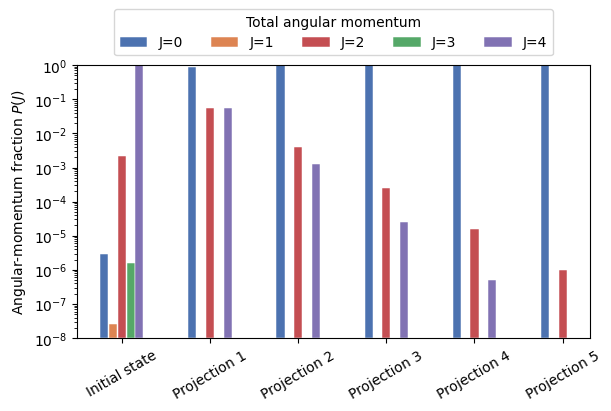

In [45]:
# Visualization 1: evolution of the total-J composition.
stage_indices = np.arange(len(projection_labels))
fig, ax = plt.subplots(
    figsize=(6, 4),
    constrained_layout=True,
)
mycols = sns.color_palette("deep")
#mycols[0], mycols[1] = mycols[1], mycols[0]
mycols[2], mycols[3] = mycols[3], mycols[2]
group_width = 0.5
bar_width = group_width / len(all_j_values)
probability_floor = 1e-8


for row, (j_value, color) in enumerate(zip(all_j_values, mycols)):
    probabilities = j_probability_matrix[row]
    offset = (row - (len(all_j_values) - 1) / 2) * bar_width
    visible = probabilities > probability_floor
    ax.bar(
        stage_indices[visible] + offset,
        probabilities[visible] - probability_floor,
        bottom=probability_floor,
        width=0.92 * bar_width,
        color=color,
        edgecolor="w",
        linewidth=0.35,
        label=f"J={j_value:g}",
    )

ax.set_xticks(stage_indices, projection_labels, rotation=30)
ax.set_yscale("log")
ax.set_ylim(probability_floor, 1.0)
ax.set_ylabel(r"Angular-momentum fraction $P(J)$")

# Reserve empty space on the right so that the legend remains inside the axes
# without covering any bars.
legend_columns = 1 if len(all_j_values) <= 6 else 2
legend_space = 1.5 if legend_columns == 1 else 2.7
#ax.set_xlim(-0.6, len(projection_labels) - 0.4 + legend_space)
ax.legend(
    title="Total angular momentum",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.23),
    ncol=len(all_j_values),  
    frameon=True,
    facecolor="white",
    edgecolor="0.8",
)
plt.savefig("J_weight_history_" + nuc + ".pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()